In [2]:
import requests
from io import StringIO
import pandas as pd
import numpy as np

In [3]:
url="https://raw.githubusercontent.com/campusx-official/100-days-of-machine-learning/refs/heads/main/day20-univariate-analysis/train.csv"
req=requests.get(url).text
data=StringIO(req)
df=pd.read_csv(data)
df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Handling mixed variable

In [4]:
df["cabin_cat"]=df["Cabin"].str.extract("(\d+)")
df["cabin_num"]=df["Cabin"].str[0]

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_15889/1480880559.py:1: SyntaxWarning: invalid escape sequence '\d'
  df["cabin_cat"]=df["Cabin"].str.extract("(\d+)")


In [5]:
df["cabin_cat"].fillna(0,inplace=True)
df["cabin_num"].fillna(0,inplace=True)

/tmp/ipykernel_15889/1538425197.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["cabin_cat"].fillna(0,inplace=True)
/tmp/ipykernel_15889/1538425197.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'd

In [6]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,cabin_cat,cabin_num
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,0,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,0,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,123,C
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,0,0
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,42,B
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,0,0
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,148,C


<Axes: xlabel='cabin_num'>

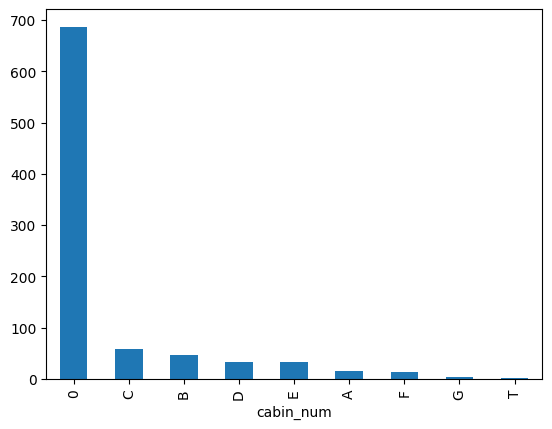

In [10]:
df.cabin_num.value_counts().plot(kind="bar")

Handling date and time

In [12]:
url="https://raw.githubusercontent.com/campusx-official/100-days-of-machine-learning/refs/heads/main/day34-handling-date-and-time/orders.csv"
req=requests.get(url).text
datas=StringIO(req)
date=pd.read_csv(datas)
date.head()

,date,product_id,city_id,orders
0,2019-12-10,5628,25,3
1,2018-08-15,3646,14,157
2,2018-10-23,1859,25,1
3,2019-08-17,7292,25,1
4,2019-01-06,4344,25,3


In [14]:
#converting objects into datetime

date["date"]=pd.to_datetime(date["date"])

In [15]:
date.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   date        1000 non-null   datetime64[ns]
 1   product_id  1000 non-null   int64         
 2   city_id     1000 non-null   int64         
 3   orders      1000 non-null   int64         
dtypes: datetime64[ns](1), int64(3)
memory usage: 31.4 KB


In [16]:
url="https://raw.githubusercontent.com/campusx-official/100-days-of-machine-learning/refs/heads/main/day34-handling-date-and-time/messages.csv"
req=requests.get(url).text
datas=StringIO(req)
time=pd.read_csv(datas)
time.head()

,date,msg
0,2013-12-15 00:50:00,ищу на сегодня мужика 37
1,2014-04-29 23:40:00,ПАРЕНЬ БИ ИЩЕТ ДРУГА СЕЙЧАС!! СМС ММС 0955532826
2,2012-12-30 00:21:00,Днепр.м 43 позн.с д/ж *.о 067.16.34.576
3,2014-11-28 00:31:00,КИЕВ ИЩУ Д/Ж ДО 45 МНЕ СЕЙЧАС СКУЧНО 093 629 9...
4,2013-10-26 23:11:00,Зая я тебя никогда не обижу люблю тебя!) Даше


In [18]:
date["year"]=date.date.dt.year

In [24]:
date["month"]=date.date.dt.month

In [25]:
date["days"]=date.date.dt.day


In [26]:
date

,date,product_id,city_id,orders,year,days,month
0,2019-12-10,5628,25,3,10,10,12
1,2018-08-15,3646,14,157,15,15,8
2,2018-10-23,1859,25,1,23,23,10
3,2019-08-17,7292,25,1,17,17,8
4,2019-01-06,4344,25,3,6,6,1
...,...,...,...,...,...,...,...
995,2018-10-08,255,13,1,8,8,10
996,2018-12-06,5521,7,1,6,6,12
997,2019-05-07,487,26,14,7,7,5
998,2019-03-03,1503,21,2,3,3,3


In [34]:

date['date_month_name'] = date['date'].dt.month_name()
date.head()

,date,product_id,city_id,orders,year,days,month,date_month_name,date_day_name
0,2019-12-10,5628,25,3,10,10,12,December,1
1,2018-08-15,3646,14,157,15,15,8,August,2
2,2018-10-23,1859,25,1,23,23,10,October,1
3,2019-08-17,7292,25,1,17,17,8,August,5
4,2019-01-06,4344,25,3,6,6,1,January,6


In [35]:


date['date_day'] = date['date'].dt.dayofweek

In [36]:
date

,date,product_id,city_id,orders,year,days,month,date_month_name,date_day_name,date_day
0,2019-12-10,5628,25,3,10,10,12,December,1,1
1,2018-08-15,3646,14,157,15,15,8,August,2,2
2,2018-10-23,1859,25,1,23,23,10,October,1,1
3,2019-08-17,7292,25,1,17,17,8,August,5,5
4,2019-01-06,4344,25,3,6,6,1,January,6,6
...,...,...,...,...,...,...,...,...,...,...
995,2018-10-08,255,13,1,8,8,10,October,0,0
996,2018-12-06,5521,7,1,6,6,12,December,3,3
997,2019-05-07,487,26,14,7,7,5,May,1,1
998,2019-03-03,1503,21,2,3,3,3,March,6,6


In [39]:

date['date_day_name'] = date['date'].dt.day_name()

In [40]:
date

,date,product_id,city_id,orders,year,days,month,date_month_name,date_day_name,date_day
0,2019-12-10,5628,25,3,10,10,12,December,Tuesday,1
1,2018-08-15,3646,14,157,15,15,8,August,Wednesday,2
2,2018-10-23,1859,25,1,23,23,10,October,Tuesday,1
3,2019-08-17,7292,25,1,17,17,8,August,Saturday,5
4,2019-01-06,4344,25,3,6,6,1,January,Sunday,6
...,...,...,...,...,...,...,...,...,...,...
995,2018-10-08,255,13,1,8,8,10,October,Monday,0
996,2018-12-06,5521,7,1,6,6,12,December,Thursday,3
997,2019-05-07,487,26,14,7,7,5,May,Tuesday,1
998,2019-03-03,1503,21,2,3,3,3,March,Sunday,6


In [42]:
date["weekend"]=np.where(date.date_day_name.isin(["Sunday","Saturday"]),1,0)

In [44]:
date.sample(15)

,date,product_id,city_id,orders,year,days,month,date_month_name,date_day_name,date_day,weekend
594,2019-04-14,547,4,86,14,14,4,April,Sunday,6,1
630,2018-11-29,6850,1,1,29,29,11,November,Thursday,3,0
816,2019-02-15,6634,25,5,15,15,2,February,Friday,4,0
844,2019-04-03,4635,22,5,3,3,4,April,Wednesday,2,0
277,2018-11-21,2017,11,3,21,21,11,November,Wednesday,2,0
249,2018-12-14,2265,25,1,14,14,12,December,Friday,4,0
117,2019-05-20,1556,17,2,20,20,5,May,Monday,0,0
647,2018-09-05,6556,23,2,5,5,9,September,Wednesday,2,0
586,2019-06-26,2563,18,8,26,26,6,June,Wednesday,2,0
540,2018-09-26,7350,16,23,26,26,9,September,Wednesday,2,0


In [48]:
date["quarter"]=np.where(date.date_month_name.isin(["January","February","March","April","May","June","July"]),1,2)

In [49]:
date.head()

,date,product_id,city_id,orders,year,days,month,date_month_name,date_day_name,date_day,weekend,quarter
0,2019-12-10,5628,25,3,10,10,12,December,Tuesday,1,0,2
1,2018-08-15,3646,14,157,15,15,8,August,Wednesday,2,0,2
2,2018-10-23,1859,25,1,23,23,10,October,Tuesday,1,0,2
3,2019-08-17,7292,25,1,17,17,8,August,Saturday,5,1,2
4,2019-01-06,4344,25,3,6,6,1,January,Sunday,6,1,1
